# CCGT+CCS NPV simulation

Run the CCGT+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_ccgt_ccs_npv

In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_ccgt_ccs_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2540.495850,45.966354,5.417446,1.939655,...,94070000.0,9.885237e+06,5.417446e+06,4.285360e+07,8.748573e+05,3.503886e+07,-1.723112e+08,25000000.0,-6.892449,-0.000007
1,1,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2129.150468,35.302676,6.488534,1.931916,...,94070000.0,7.591973e+06,6.488534e+06,9.300487e+07,1.903189e+06,-1.491857e+07,-6.171342e+08,25000000.0,-24.685367,-0.000025
2,2,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1513.439721,49.883696,6.245139,1.926855,...,94070000.0,1.072768e+07,6.245139e+06,1.135923e+08,8.176112e+05,-3.731269e+07,-7.237755e+08,25000000.0,-28.951019,-0.000029
3,3,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2069.539060,53.825154,6.529694,1.923692,...,94070000.0,1.157530e+07,6.529694e+06,5.451503e+07,3.115662e+06,1.833431e+07,-2.493475e+08,25000000.0,-9.973900,-0.000010
4,4,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2256.703398,49.194197,5.690937,1.919179,...,94070000.0,1.057940e+07,5.690937e+06,7.913833e+07,2.205524e+06,-3.544187e+06,-5.231460e+08,25000000.0,-20.925838,-0.000021


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1.000000e+06
mean,-425.444355,-17.017774,-1.701777e-05
std,297.850580,11.914023,1.191402e-05
min,-1534.939167,-61.397567,-6.139757e-05
5%,-959.478537,-38.379141,-3.837914e-05
50%,-397.165155,-15.886606,-1.588661e-05
95%,12.430061,0.497202,4.972024e-07
max,276.754517,11.070181,1.107018e-05


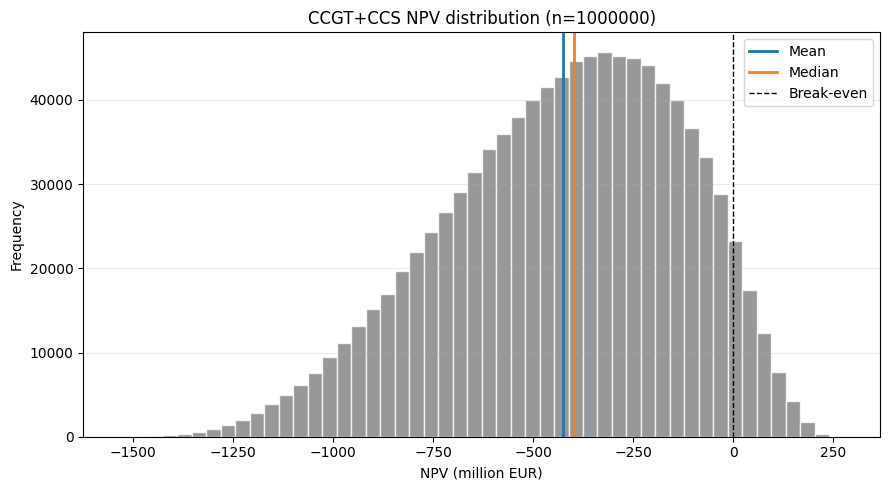

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


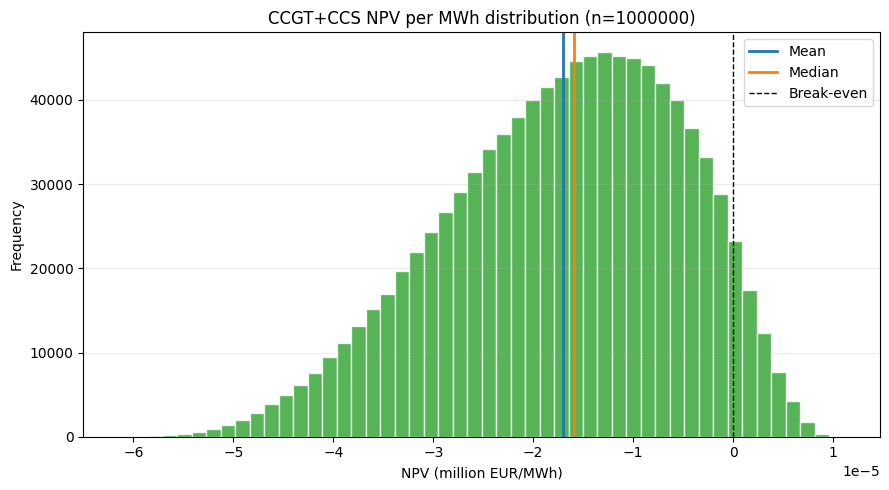

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.618871
annual_variable_opex_eur      6.276013
annual_fuel_cost_eur         75.503394
annual_emissions_cost_eur     1.790531
annual_net_cash_flow_eur      0.881191
Name: Mean annual value, million EUR, dtype: float64